<a href="https://colab.research.google.com/github/Tuhin092005/Project_2_Network_Intrusion_Detection_System_Using_Machine_Learning/blob/main/Network_Intrusion_Detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Upload the dataset

from google.colab import files

uploaded = files.upload()

Saving KDDTrain+.txt to KDDTrain+ (3).txt
Saving KDDTest+.txt to KDDTest+ (3).txt


In [ ]:
# Define column names

columns = [
    'duration','protocol_type','service','flag','src_bytes',
    'dst_bytes','land','wrong_fragment','urgent','hot',
    'num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count',
    'serror_rate','srv_serror_rate','rerror_rate',
    'srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'attack','difficulty'
]

In [ ]:
# Load the training and testing datasets

train_df = pd.read_csv("KDDTrain+.txt", names=columns)
test_df = pd.read_csv("KDDTest+.txt", names=columns)

In [ ]:
# Preview / Display the training dataset

train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
# Display training dataset information

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [ ]:
# Preview / Display the test dataset

test_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,difficulty
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [ ]:
# Display test dataset information

test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22544 non-null  int64  
 1   protocol_type                22544 non-null  object 
 2   service                      22544 non-null  object 
 3   flag                         22544 non-null  object 
 4   src_bytes                    22544 non-null  int64  
 5   dst_bytes                    22544 non-null  int64  
 6   land                         22544 non-null  int64  
 7   wrong_fragment               22544 non-null  int64  
 8   urgent                       22544 non-null  int64  
 9   hot                          22544 non-null  int64  
 10  num_failed_logins            22544 non-null  int64  
 11  logged_in                    22544 non-null  int64  
 12  num_compromised              22544 non-null  int64  
 13  root_shell      

In [ ]:
# Check number of rows and columns in each dataset

print("Training Data:", train_df.shape)

print("Testing Data:", test_df.shape)

Training Data: (125973, 43)
Testing Data: (22544, 43)


In [ ]:
# Display statistical summary of training dataset

train_df.describe()


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [ ]:
# Display statistical summary of test dataset

test_df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,22544.000000,2.254400e+04,2.254400e+04,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,...,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000
mean,218.859076,1.039545e+04,2.056019e+03,0.000311,0.008428,0.000710,0.105394,0.021647,0.442202,0.119899,...,140.750532,0.608722,0.090540,0.132261,0.019638,0.097814,0.099426,0.233385,0.226683,18.017965
std,1407.176612,4.727864e+05,2.121930e+04,0.017619,0.142599,0.036473,0.928428,0.150328,0.496659,7.269597,...,111.783972,0.435688,0.220717,0.306268,0.085394,0.273139,0.281866,0.387229,0.400875,4.270361
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,15.000000,0.070000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000
50%,0.000000,5.400000e+01,4.600000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,168.000000,0.920000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.000000,2.870000e+02,6.010000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.060000,0.030000,0.010000,0.000000,0.000000,0.360000,0.170000,21.000000
max,57715.000000,6.282565e+07,1.345927e+06,1.000000,3.000000,3.000000,101.000000,4.000000,1.000000,796.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [ ]:
# Check missing values in the training and testing datasets

train_df.isnull().sum()
train_df.fillna(train_df.mean(numeric_only=True), inplace=True)

test_df.isnull().sum()
test_df.fillna(test_df.mean(numeric_only=True), inplace=True)

In [ ]:
# Check duplicate rows in the training and testing datasets

train_df.duplicated().sum()
train_df.drop_duplicates(inplace=True)

test_df.duplicated().sum()
test_df.drop_duplicates(inplace=True)

In [ ]:
# Check target column in the training and testing datasets

print(train_df['attack'].value_counts())
print()
print(test_df['attack'].value_counts())

attack
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

attack
normal             9711
neptune            4657
guess_passwd       1231
mscan               996
warezmaster         944
apache2             737
satan               735
processtable        685
smurf               665
back                359
snmpguess           331
saint               319
mailbomb            293
snmpgetattack       178
portsweep           157
ipsweep             141


In [ ]:
# Convert attack labels into binary values

train_df['attack'] = train_df['attack'].apply(
    lambda x: 0 if x == 'normal' else 1
)

test_df['attack'] = test_df['attack'].apply(
    lambda x: 0 if x == 'normal' else 1
)

In [ ]:
# Separate input features and target variable

X_train = train_df.drop(['attack','difficulty'], axis=1)

y_train = train_df['attack']


X_test = test_df.drop(['attack','difficulty'], axis=1)

y_test = test_df['attack']

In [ ]:
# Save feature names

feature_names = X_train.columns

In [ ]:
categorical_columns = X_train.select_dtypes(include='object').columns

label_encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()

    X_train[column] = encoder.fit_transform(X_train[column])

    X_test[column] = encoder.transform(X_test[column])

    label_encoders[column] = encoder

In [ ]:
# Scale feature values

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
# Train Logistic Regression model

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train,y_train)

y_pred_lr = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test,y_pred_lr)

print(f"Accuracy of the Logistic Regression: {lr_accuracy * 100:.2f}%")

Accuracy of the Logistic Regression: 75.39%


In [ ]:
# Train Decision Tree Classifier

dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train,y_train)

y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test,y_pred_dt)

print(f"Accuracy of the Decision Tree: {dt_accuracy * 100:.2f}%")

Accuracy of the Decision Tree: 76.34%


In [ ]:
# Train Random Forest Classifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train,y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test,y_pred_rf)

print(f"Accuracy of the Random Forest: {rf_accuracy * 100:.2f}%")

Accuracy of the Random Forest: 76.70%


In [ ]:
# Compare model accuracy

model_comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy(%)":[
        lr_accuracy*100,
        dt_accuracy*100,
        rf_accuracy*100
    ]

})


model_comparison

,Model,Accuracy(%)
0,Logistic Regression,75.390348
1,Decision Tree,76.344038
2,Random Forest,76.703336


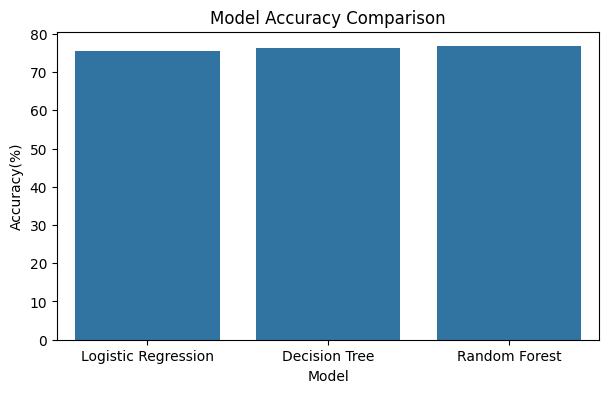

In [ ]:
# Plot model accuracy comparison

plt.figure(figsize=(7,4))

sns.barplot(
    x="Model",
    y="Accuracy(%)",
    data=model_comparison
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy(%)")

plt.show()

In [ ]:
# Find the best model

best_model = model_comparison.loc[
    model_comparison["Accuracy(%)"].idxmax()
]

print(best_model)

Model          Random Forest
Accuracy(%)        76.703336
Name: 2, dtype: object


In [ ]:
# Selecting Random Forest as the final model

final_model = rf_model

In [ ]:
# Creating Confusion Matrix

cm = confusion_matrix(y_test, y_pred_rf)

print(cm)

[[9443  268]
 [4984 7849]]


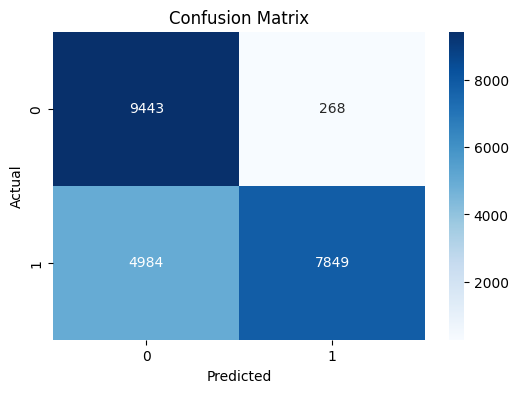

In [ ]:
# Plotting Confusion Matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# Display classification report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.65      0.97      0.78      9711
           1       0.97      0.61      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.77     22544
weighted avg       0.83      0.77      0.76     22544



In [ ]:
# Calculate feature importance

feature_importance = pd.DataFrame({

    "Feature": train_df.drop(['attack', 'difficulty'], axis=1).columns,
    "Importance": rf_model.feature_importances_

})

In [ ]:
# Sort feature importance

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
4,src_bytes,0.190063
5,dst_bytes,0.099994
3,flag,0.089856
28,same_srv_rate,0.086072
33,dst_host_same_srv_rate,0.071034
29,diff_srv_rate,0.051947
32,dst_host_srv_count,0.047041
11,logged_in,0.043113
34,dst_host_diff_srv_rate,0.036374
1,protocol_type,0.034511


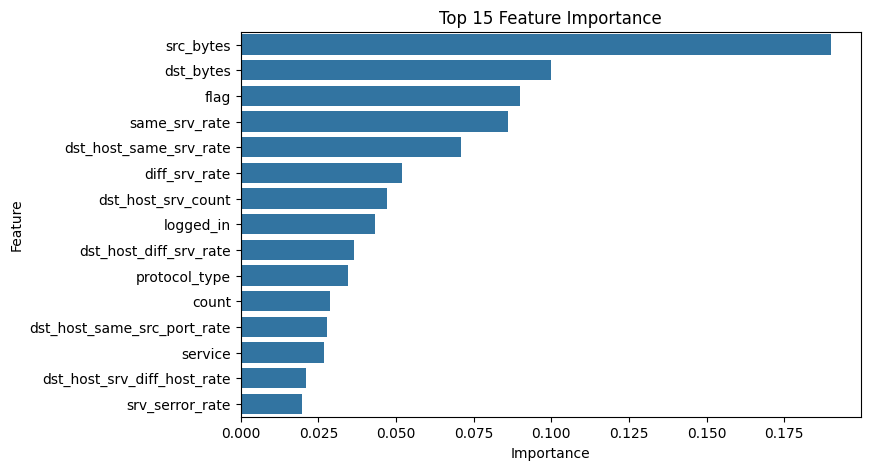

In [ ]:
# Plot feature importance

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(15)
)

plt.title("Top 15 Feature Importance")

plt.show()

In [ ]:
# Function for intrusion prediction

def predict_intrusion(input_data):

    input_df = pd.DataFrame(
        [input_data],
        columns=feature_names
    )

    for col in categorical_columns:
        input_df[col] = label_encoders[col].transform(
            input_df[col]
        )

    input_scaled = scaler.transform(input_df)

    prediction = final_model.predict(input_scaled)

    return prediction[0]

In [ ]:
# Create new data

new_data = {
    'duration': 0,
    'protocol_type': 'tcp',
    'service': 'http',
    'flag': 'SF',
    'src_bytes': 181,
    'dst_bytes': 5450,
    'land': 0,
    'wrong_fragment': 0,
    'urgent': 0,
    'hot': 0,
    'num_failed_logins': 0,
    'logged_in': 1,
    'num_compromised': 0,
    'root_shell': 0,
    'su_attempted': 0,
    'num_root': 0,
    'num_file_creations': 0,
    'num_shells': 0,
    'num_access_files': 0,
    'num_outbound_cmds': 0,
    'is_host_login': 0,
    'is_guest_login': 0,
    'count': 9,
    'srv_count': 9,
    'serror_rate': 0.0,
    'srv_serror_rate': 0.0,
    'rerror_rate': 0.0,
    'srv_rerror_rate': 0.0,
    'same_srv_rate': 1.0,
    'diff_srv_rate': 0.0,
    'srv_diff_host_rate': 0.0,
    'dst_host_count': 255,
    'dst_host_srv_count': 9,
    'dst_host_same_srv_rate': 0.04,
    'dst_host_diff_srv_rate': 0.06,
    'dst_host_same_src_port_rate': 0.00,
    'dst_host_srv_diff_host_rate': 0.00,
    'dst_host_serror_rate': 0.00,
    'dst_host_srv_serror_rate': 0.00,
    'dst_host_rerror_rate': 0.00,
    'dst_host_srv_rerror_rate': 0.00
}

In [ ]:
# Predict network intrusion

result = predict_intrusion(new_data)

print("Prediction:", result)

Prediction: 0


In [ ]:
# Display prediction result

if (result == 1):
    print("⚠️ Intrusion Detected")

else:
    print("✅ Normal Network Traffic")

✅ Normal Network Traffic


In [ ]:
# Create another new data

new_data1 = {
    'duration': 120,
    'protocol_type': 'tcp',
    'service': 'ftp_data',
    'flag': 'S0',
    'src_bytes': 5000,
    'dst_bytes': 0,
    'land': 0,
    'wrong_fragment': 0,
    'urgent': 0,
    'hot': 5,
    'num_failed_logins': 4,
    'logged_in': 0,
    'num_compromised': 3,
    'root_shell': 1,
    'su_attempted': 1,
    'num_root': 2,
    'num_file_creations': 3,
    'num_shells': 1,
    'num_access_files': 2,
    'num_outbound_cmds': 0,
    'is_host_login': 0,
    'is_guest_login': 1,
    'count': 250,
    'srv_count': 250,
    'serror_rate': 1.0,
    'srv_serror_rate': 1.0,
    'rerror_rate': 0.8,
    'srv_rerror_rate': 0.8,
    'same_srv_rate': 0.1,
    'diff_srv_rate': 0.9,
    'srv_diff_host_rate': 0.8,
    'dst_host_count': 255,
    'dst_host_srv_count': 5,
    'dst_host_same_srv_rate': 0.02,
    'dst_host_diff_srv_rate': 0.90,
    'dst_host_same_src_port_rate': 0.90,
    'dst_host_srv_diff_host_rate': 0.80,
    'dst_host_serror_rate': 1.0,
    'dst_host_srv_serror_rate': 1.0,
    'dst_host_rerror_rate': 0.9,
    'dst_host_srv_rerror_rate': 0.9
}

In [ ]:
# Predict network intrusion

result1 = predict_intrusion(new_data1)

print("Prediction:", result1)

Prediction: 1


In [ ]:
# Display prediction result

if (result1 == 1):
    print("⚠️ Intrusion Detected")

else:
    print("✅ Normal Network Traffic")

⚠️ Intrusion Detected
